### **Description**

Recipe showing how to extract the Overturning in the Subpolar North Atlantic (OSNAP) trans-basin hydrographic section using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using ERA-5 climatologically adjusted atmospheric forcing from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
The Overturning in the Subpolar North Atlantic Program (OSNAP) is an international program designed to provide a continuous record of the full-water column, trans-basin fluxes of heat, mass and freshwater in the subpolar North Atlantic.

The OSNAP observing system comprises of two trans-basin arrays: extending from southern Labrador to the southwestern tip of Greenland across the Labrador Sea (OSNAP West), and from the southeastern tip of Greenland to Scotland (OSNAP East).

The diapycnal overturning stream function is used to characterise the strength and structure of the AMOC in density-space (e.g., $\sigma_{0}$ or $\sigma_{2}$) across OSNAP and can be defined at time $t$ as follows:

$$\Psi(\sigma, t) = \int_{x_w}^{x_e} \int_{z(x, \sigma)}^{\eta} v(x, z', t) \ dz' \ dx$$

where the velocity field $v(x, z', t)$ normal to OSNAP array is first integrated vertically from the sea surface $\eta$ to a specified isopycnal depth $z(x, \sigma)$ before being integrated zonally between the western ($x_w$) and eastern ($x_e$) boundaries of the subpolar basin.

---

In [1]:
# -- Import required packages -- #
import gsw
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/',
                 'local_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/'
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=5, threads_per_worker=2, memory_limit='8GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [2]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/50)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to open the conservative temperature and absolute salinity variables stored at T-points as a single dataset.**

**Here, for simplicity, we will only consider the time-period from 2014-2023**

In [3]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including conservative temperature (deg C) and absolute salinity (g/kg) variables:
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={}).sel(time_counter=slice("2014-01", "2023-12"))

# Calculate potential density anomaly referenced to the sea surface (kg/m3):
ds_gridT['sigma0'] = gsw.density.sigma0(CT=ds_gridT['thetao_con'], SA=ds_gridT['so_abs'])
ds_gridT['sigma0'].name = 'sigma0'

ds_gridT

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 10, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 80B 2014-07-02T12:00...
    time_centered          (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/75)
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    vohfcisf               (time_counter, deptht, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    sigma0                 (time_counter, deptht, y, x) float64 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

**Next, we need to import the zonal & meridional velocities and vertical grid cell thicknesses stored at U- & V-points, respectively.**

In [4]:
# Define directory path to model output files:
gridU_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1y"

# Construct NEMO model U-grid dataset, including zonal velocities (m/s) and vertical grid cell thicknesses (m):
ds_gridU = xr.open_zarr(gridU_url, consolidated=True, chunks={}).sel(time_counter=slice("2014-01", "2023-12"))

ds_gridU

<xarray.Dataset> Size: 2GB
Dimensions:               (depthu: 75, axis_nbounds: 2, time_counter: 10,
                           y: 331, x: 360)
Coordinates:
  * depthu                (depthu) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 80B 2014-07-02T12:00:...
    time_centered         (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/14)
    depthu_bounds         (depthu, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3u                   (time_counter, depthu, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfx                   (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_adv               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_diff              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    sozosatr              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 160B dask.array<chunksize=(1, 2), meta=np.ndarray>
    u2o                   (time_counter, depthu, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo                   (time_counter, depthu, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo_vint              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    uo                    (time_counter, depthu, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    uo_eiv                (time_counter, depthu, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_U
    description:  ocean U grid variables
    title:        ocean U grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         8156ec68-1106-4f56-9f8c-d8798e1bd32f

In [5]:
# Define directory path to model output files:
gridV_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1y"

# Construct NEMO model V-grid dataset, including meridional velocities (m/s) and vertical grid cell thicknesses (m):
ds_gridV = xr.open_zarr(gridV_url, consolidated=True, chunks={}).sel(time_counter=slice("2014-01", "2023-12"))

ds_gridV

<xarray.Dataset> Size: 2GB
Dimensions:               (depthv: 75, axis_nbounds: 2, time_counter: 10,
                           y: 331, x: 360)
Coordinates:
  * depthv                (depthv) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 80B 2014-07-02T12:00:...
    time_centered         (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/13)
    depthv_bounds         (depthv, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfy                   (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_adv               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_diff              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    somesatr              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 160B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 160B dask.array<chunksize=(1, 2), meta=np.ndarray>
    v2o                   (time_counter, depthv, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vmo                   (time_counter, depthv, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo                    (time_counter, depthv, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo_eiv                (time_counter, depthv, y, x) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T, U & V-grid variables for the eORCA1 model.**

In [6]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent":
            {"domain": ds_domain,
             "gridT": ds_gridT,
             "gridU": ds_gridU,
             "gridV": ds_gridV
             }
            }

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 10, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 80B 2014-07-02T12:00:...
│       time_centered         (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 160B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 160B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 10, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│           time_centered          (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/79)
│           berg_latent_heat_flux  (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 357MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           zossq                  (time_counter, j, i) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           sigma0                 (time_counter, k, j, i) float64 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           name:         OUTPUT/eORCA1_1y_grid_T
│           description:  ocean T grid variables
│           title:        ocean T grid variables
│           Conventions:  CF-1.6
│           timeStamp:    2024-Dec-09 10:28:01 GMT
│           uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b
├── Group: /gridU
│       Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 10, j: 331,
│                                  i: 360)
│       Coordinates:
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * depthu                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered         (time_counter) datetime64[ns] 80B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) float64 3kB 1.5 2.5 3.5 4.5 ... 35

### **Preparing OSNAP Coordinates**

**Next, we will prepare geographical (lat, lon) coordinates defining the Overturning in the Subpolar North Atlantic (OSNAP) array from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/).**


In [7]:
# Define S3 URL to OSNAP gridded observational data in JASMIN Object Store:
url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/ocean-obs/OSNAP/OSNAP_Gridded_TSV_201408_202006_2023"
ds_osnap = xr.open_zarr(url, consolidated=True, chunks={})

# Define OSNAP section coordinates (adding final land point -> UK):
lon_osnap = np.concatenate([ds_osnap['LONGITUDE'].values, np.array([-4.0])])
lat_osnap = np.concatenate([ds_osnap['LATITUDE'].values, np.array([56.0])])

### **Extracting the OSNAP array as a continuous hydrographic section**

**Now, let's use the `extract_section()` function to extract the OSNAP array from our NEMO model output.**

**We need to provide the names of the zonal & meridional velocity variables (`uv_vars=["uo", "vo"]`) and any scalar variables (e.g. potential density `vars=sigma0`) to extract along the secton.**

In [8]:
# Extract the OSNAP section from the NEMO model data:
ds_osnap = nemo.extract_section(lon=lon_osnap,
                                lat=lat_osnap,
                                uv_vars=["uo", "vo"],
                                vars=["sigma0"],
                                dom=".",
                                )

ds_osnap

<xarray.Dataset> Size: 1MB
Dimensions:       (bdy: 68, time_counter: 10, k: 75)
Coordinates:
  * bdy           (bdy) int64 544B 0 1 2 3 4 5 6 7 8 ... 60 61 62 63 64 65 66 67
    glamb         (bdy) float64 544B -56.74 -55.72 -54.7 ... -5.497 -4.411
    gphib         (bdy) float64 544B 51.89 51.96 52.03 ... 56.5 56.16 56.08
    depthb        (k, bdy) float64 41kB 0.5058 0.5058 ... 5.902e+03 5.902e+03
  * time_counter  (time_counter) datetime64[ns] 80B 2014-07-02T12:00:00 ... 2...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
Data variables:
    i_bdy         (bdy) float64 544B 232.0 233.0 234.0 ... 279.5 280.0 281.0
    j_bdy         (bdy) float64 544B 263.5 263.5 263.5 ... 270.0 269.5 269.5
    flux_type     (bdy) <U1 272B 'V' 'V' 'V' 'U' 'V' 'V' ... 'V' 'V' 'U' 'V' 'V'
    flux_dir      (bdy) int64 544B 1 1 1 -1 1 1 1 1 -1 1 ... 1 1 1 1 1 1 1 1 1 1
    velocity      (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    bmask         (k, bdy) float64 41kB dask.array<chunksize=(75, 68), meta=np.ndarray>
    e1b           (bdy) float64 544B dask.array<chunksize=(68,), meta=np.ndarray>
    e3b           (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    sigma0        (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>

### **Visualising properties along the OSNAP array**

**Next, let's plot the time-mean potential density along the OSNAP array:**

(4000.0, 0.0)

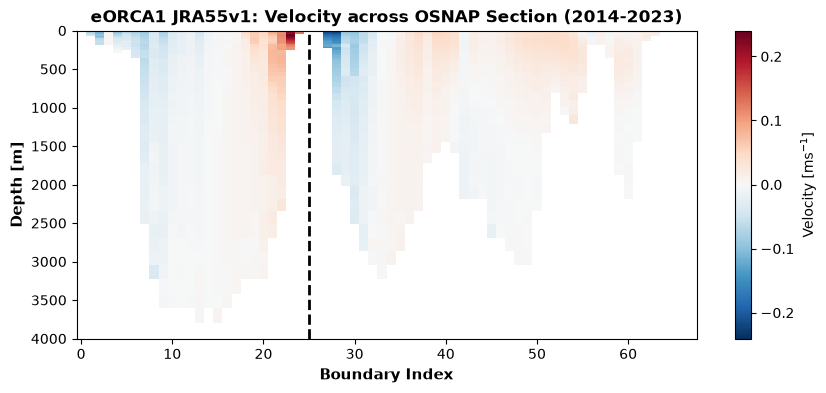

In [9]:
# -- Plot the time-mean velocity along the OSNAP section -- #
plt.figure(figsize=(10, 4))

# Plot time-mean velocity across OSNAP section:
ds_osnap['velocity'].mean(dim='time_counter').plot(y='depthb', yincrease=False, cbar_kwargs={"label": "Velocity [ms$^{-1}$]"})

# Plot OSNAP West - East reference line:
plt.axvline(x=ds_osnap['bdy'].where(ds_osnap['glamb'] <= -44).max(), color='k', lw=2, ls='--')

# Axes labels:
plt.title("eORCA1 JRA55v1: Velocity across OSNAP Section (2014-2023)", fontdict={'size':12, 'weight':'bold'})
plt.xlabel("Boundary Index", fontdict={'size':11, 'weight':'bold'})
plt.ylabel("Depth [m]", fontdict={'size':11, 'weight':'bold'})
plt.ylim([4000, 0])

### **Calculating Meridional Overturning Stream Functions along the OSNAP array**

**Finally, let's calculate the meridional overturning stream function in potential density coordinates along the OSNAP array using the `.compute_binned_statistic()` function:**

In [10]:
from nemo_cookbook.stats import compute_binned_statistic

# Calculate volume transport in Sv:
ds_osnap['volume_transport'] = 1E-6 * (ds_osnap['velocity'] * ds_osnap['e1b'] * ds_osnap['e3b'])

# Define potential density bins:
sigma0_bins = np.arange(21, 28.2, 0.01)

# Compute Total OSNAP diapycnal overturning stream function:
ds_osnap['moc_total'] = compute_binned_statistic(vars=[ds_osnap['sigma0']],
                                                 values=ds_osnap['volume_transport'],
                                                 keep_dims=['time_counter'],
                                                 bins=[sigma0_bins],
                                                 statistic='nansum',
                                                 mask=None
                                                 ).cumsum(dim='sigma0_bins')

**Next, let's calculate the meridional overturning stream functions for the OSNAP East and OSNAP West arrays separately.**

In [11]:
# Determine index to split OSNAP West & OSNAP East sections:
station_OWest_OEast = ds_osnap['bdy'].where(ds_osnap['glamb'] <= -44).max()

# OSNAP East diapycnal overturning stream function:
mask_OEast = ds_osnap['bdy'] >= station_OWest_OEast
ds_osnap['moc_east'] = compute_binned_statistic(vars=[ds_osnap['sigma0']],
                                                values=ds_osnap['volume_transport'],
                                                keep_dims=['time_counter'],
                                                bins=[sigma0_bins],
                                                statistic='nansum',
                                                mask=mask_OEast
                                                ).cumsum(dim='sigma0_bins')

# OSNAP West diapycnal overturning stream function:
mask_OWest = ds_osnap['bdy'] < station_OWest_OEast
ds_osnap['moc_west'] = compute_binned_statistic(vars=[ds_osnap['sigma0']],
                                                values=ds_osnap['volume_transport'],
                                                keep_dims=['time_counter'],
                                                bins=[sigma0_bins],
                                                statistic='nansum',
                                                mask=mask_OWest
                                                ).cumsum(dim='sigma0_bins')

ds_osnap

<xarray.Dataset> Size: 2MB
Dimensions:           (bdy: 68, time_counter: 10, k: 75, sigma0_bins: 719)
Coordinates:
  * bdy               (bdy) int64 544B 0 1 2 3 4 5 6 7 ... 61 62 63 64 65 66 67
    glamb             (bdy) float64 544B -56.74 -55.72 -54.7 ... -5.497 -4.411
    gphib             (bdy) float64 544B 51.89 51.96 52.03 ... 56.5 56.16 56.08
    depthb            (k, bdy) float64 41kB 0.5058 0.5058 ... 5.902e+03
  * time_counter      (time_counter) datetime64[ns] 80B 2014-07-02T12:00:00 ....
  * k                 (k) int64 600B 1 2 3 4 5 6 7 8 ... 68 69 70 71 72 73 74 75
  * sigma0_bins       (sigma0_bins) float64 6kB 21.01 21.02 ... 28.18 28.19
Data variables: (12/13)
    i_bdy             (bdy) float64 544B 232.0 233.0 234.0 ... 279.5 280.0 281.0
    j_bdy             (bdy) float64 544B 263.5 263.5 263.5 ... 270.0 269.5 269.5
    flux_type         (bdy) <U1 272B 'V' 'V' 'V' 'U' 'V' ... 'V' 'V' 'U' 'V' 'V'
    flux_dir          (bdy) int64 544B 1 1 1 -1 1 1 1 1 -1 ... 1 1 1 1 1 1 1 1 1
    velocity          (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    bmask             (k, bdy) float64 41kB dask.array<chunksize=(75, 68), meta=np.ndarray>
    ...                ...
    e3b               (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    sigma0            (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    volume_transport  (time_counter, k, bdy) float64 408kB dask.array<chunksize=(10, 75, 68), meta=np.ndarray>
    moc_total         (time_counter, sigma0_bins) float64 58kB dask.array<chunksize=(10, 719), meta=np.ndarray>
    moc_east          (time_counter, sigma0_bins) float64 58kB dask.array<chunksize=(10, 719), meta=np.ndarray>
    moc_west          (time_counter, sigma0_bins) float64 58kB dask.array<chunksize=(10, 719), meta=np.ndarray>

**Notice that the resulting Dataset includes dask arrays, so we haven't actually computed the diapycnal overturning yet. To do this, we need to call the ``.compute()`` method:**

In [13]:
ds_osnap = ds_osnap.compute()

### **Visualising the time-mean diapycnal overturning stream functions**

**Finally, let's visualise the results by plotting the time-mean OSNAP overturning stream functions in potential density-coordinates:**

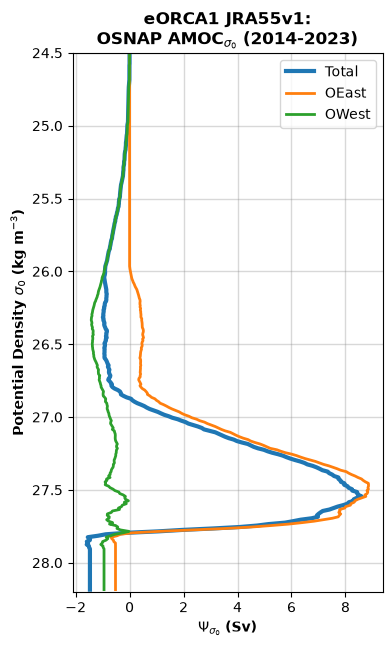

In [14]:
# Plot time-mean diapycnal overturning stream functions along the OSNAP section:
plt.figure(figsize=(4, 7))
plt.grid(True, lw=1, color='0.5', alpha=0.3)

# Plot Osnap Total, OSNAP East & OSNAP West diapycnal overturning stream functions:
ds_osnap['moc_total'].mean(dim='time_counter').plot(yincrease=False, y='sigma0_bins', label='Total', lw=3)
ds_osnap['moc_east'].mean(dim='time_counter').plot(yincrease=False, y='sigma0_bins', label='OEast', lw=2)
ds_osnap['moc_west'].mean(dim='time_counter').plot(yincrease=False, y='sigma0_bins', label='OWest', lw=2)

# Axes labels:
plt.title("eORCA1 JRA55v1:\nOSNAP AMOC$_{\\sigma_{0}}$ (2014-2023)", fontdict={"size": 12, "weight": "bold"})
plt.xlabel("$\\Psi_{\\sigma_0}$ (Sv)", fontdict={"size": 10, "weight": "bold"})
plt.ylabel("Potential Density $\\sigma_0$ (kg m$^{-3}$)", fontdict={"size": 10, "weight": "bold"})
plt.ylim([28.2, 24.5])
plt.legend()